## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
EXPERIMENT_NAME='TL/1_vgg16'
assert(not EXPERIMENT_NAME is None)

import tensorflow as tf
import uuid
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import warnings
import rasterio
import json
import glob
import shutil

# Reduce TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Activation, Rescaling
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import TerminateOnNaN, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

%matplotlib inline
print(tf.config.list_physical_devices('GPU'))

2025-11-15 12:13:36.061083: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# PROJECT_PATH = "/workspace/COMPUTERVISIONPROYECT"
PROJECT_PATH = os.getcwd()
PROJECT_PATH = "/mnt/c/Users/Yeray/Desktop/MUIA/Computer Vision/COMPUTERVISIONPROYECT"
DATASET_NAME = 'stratified'

XVIEW_RECOGNITION_PATH = "../data/xview_recognition/"
# XVIEW_RECOGNITION_PATH = os.path.join(PROJECT_PATH, "data/xview_recognition")

EXPERIMENT_PATH = os.path.join(PROJECT_PATH, "experiment_results", EXPERIMENT_NAME)
EXPERIMENT_RESULTS = os.path.join(EXPERIMENT_PATH, "results")
# assert(not os.path.exists(EXPERIMENT_PATH))
# if not os.path.exists(EXPERIMENT_PATH):
#     os.mkdir(EXPERIMENT_PATH)
#     os.mkdir(EXPERIMENT_RESULTS)
CHECKPOINT_DIR = os.path.join(EXPERIMENT_PATH, 'model_checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
BEST_WEIGHTS_FILENAME_PATTERN = os.path.join(CHECKPOINT_DIR, 'epoch_{epoch:03d}-val_loss_{val_loss:.4f}.weights.h5')
MODEL_PATH = os.path.join(EXPERIMENT_PATH, 'model.keras')

CM_PATH = os.path.join(EXPERIMENT_RESULTS, 'cm.png')
METRICS_PATH = os.path.join(EXPERIMENT_RESULTS, 'metrics.csv')
ACC_LOSS_PATH = os.path.join(EXPERIMENT_RESULTS, 'acc_loss.png')
TEST_PREDICTS_PATH = os.path.join(EXPERIMENT_RESULTS, 'prediction.json')

TRAIN_SET_FILENAME = '_'.join([DATASET_NAME, 'train.tfrecord'])
VALIDATION_SET_FILENAME = '_'.join([DATASET_NAME, 'validation.tfrecord'])
TRAIN_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, TRAIN_SET_FILENAME)
VALIDATION_SET_PATH = os.path.join(XVIEW_RECOGNITION_PATH, VALIDATION_SET_FILENAME)

## Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = None
DROPOUT_RATE = None
REGULARIZER_PENALTY = None
EPOCHS = 20

categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

# Required classes and functions

In [3]:
class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [6]:
def draw_confusion_matrix(cm, categories, save_path=None, exp_name=None):
    # Draw confusion matrix
    fig = plt.figure(figsize=[3.2*pow(len(categories), 0.5), 2.4*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(15-pow(len(categories), 0.5)))
    fig.tight_layout()

    if save_path:
        if exp_name:
            plt.title(exp_name)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Gráfico guardado en: {save_path}")

    plt.show()

# 0. La usamos para las imágenes de test
def load_geoimage(filename_tensor):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    filename = filename_tensor
    src_raster = rasterio.open(filename, 'r')

    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

# 1. Función para decodificar los ejemplos del archivo
def _parse_image_function(example_proto):
    feature_description = {
        'height': tf.io.FixedLenFeature([], tf.int64),
        'width': tf.io.FixedLenFeature([], tf.int64),
        'depth': tf.io.FixedLenFeature([], tf.int64),
        'category_id': tf.io.FixedLenFeature([], tf.int64),
        'image_raw': tf.io.FixedLenFeature([], tf.string),
    }
    
    features = tf.io.parse_single_example(example_proto, feature_description)
    
    image = tf.io.decode_raw(features['image_raw'], out_type=tf.uint8)
    shape = [features['height'], features['width'], features['depth']]
    image = tf.reshape(image, shape)
    image = tf.cast(image, tf.float32)
    
    image = tf.image.resize(image, [224, 224])
    
    category_id = tf.cast(features['category_id'], tf.int32)
    label = tf.one_hot(category_id, depth=len(categories))
    
    return image, label

# 2. Función para crear el dataset
def create_tfrecord_dataset(filenames, batch_size, do_shuffle=False):
    # Lee los archivos TFRecord. Puede leer de múltiples archivos en paralelo.
    dataset = tf.data.TFRecordDataset(filenames, num_parallel_reads=tf.data.AUTOTUNE)
    
    dataset = dataset.map(_parse_image_function, num_parallel_calls=tf.data.AUTOTUNE)
    # dataset = dataset.cache()
    
    if do_shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Datasets definition

In [7]:
train_dataset = create_tfrecord_dataset([TRAIN_SET_PATH], BATCH_SIZE, do_shuffle=True)
valid_dataset = create_tfrecord_dataset([VALIDATION_SET_PATH], BATCH_SIZE)

I0000 00:00:1763205247.307344   10144 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
y_train_labels = []
for _,label_idxs in train_dataset:
    y_train_labels += list(label_idxs.numpy().argmax(axis=1))

index,freqs = np.unique(y_train_labels, return_counts=True)
categories_count = pd.Series(freqs, index=[categories[idx] for idx in index], name='Size').sort_values(ascending=False)

categories_count

2025-11-15 12:14:10.057050: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144
2025-11-15 12:14:26.112111: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Building              3235
Small car             2992
Truck                 1989
Bus                   1591
Shipping container    1371
Storage tank          1322
Dump truck            1112
Motorboat              962
Excavator              710
Fishing vessel         635
Cargo plane            571
Pylon                  281
Helipad                100
Name: Size, dtype: int64

# Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [9]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

model = Sequential(name=EXPERIMENT_NAME.split('/')[-1])
model.add(base_model)
model.add(Flatten(name='Flatten'))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(categories), activation='softmax'))

model.summary()

Model: "1_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,140,813 (80.65 MB)

 Trainable params: 6,426,125 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
opt = Adam(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Callbacks
# model_checkpoint = ModelCheckpoint(
#     filepath=BEST_WEIGHTS_FILENAME_PATTERN,
#     monitor='val_loss',
#     verbose=1,
#     save_best_only=True,
#     save_weights_only=True
# )
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.5, patience=5, verbose=1, min_lr=1e-6)
terminate = TerminateOnNaN()
early_stop = EarlyStopping('val_accuracy', patience=EPOCHS, verbose=1, restore_best_weights=False)
callbacks = [reduce_lr, early_stop, terminate]

In [12]:
print('Training model')
h = model.fit(train_dataset, 
              validation_data=valid_dataset, 
              epochs=EPOCHS, 
              callbacks=callbacks, 
              verbose=1)

checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, '*.keras'))

if checkpoints:
    # Copiamos el mejor modelo en la ruta {EXPERIMENT_PATH}/model.keras
    # Ordenar los archivos por el valor de 'val_loss' (que está en el nombre)
    # y coger el primero (el que tenga el valor más bajo)
    BEST_WEIGHTS_FILENAME = min(checkpoints, key=lambda x: float(x.split('val_loss_')[1].replace('.keras', '')))
    model.load_weights(BEST_WEIGHTS_FILENAME)
    model.save(MODEL_PATH)

    print(f"El mejor modelo se encuentra en: {MODEL_PATH}")
else:
    print("No se encontraron checkpoints.")

Training model
Epoch 1/20


2025-11-15 12:14:44.635819: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0b7c00e280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-15 12:14:44.635869: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-11-15 12:14:44.702653: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-15 12:14:45.085481: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-15 12:14:47.989963: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.05GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-15 12:14:48.49357

    131/Unknown 72s 321ms/step - accuracy: 0.3789 - loss: 3.5734

2025-11-15 12:15:55.327385: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1259', 108 bytes spill stores, 108 bytes spill loads

2025-11-15 12:15:56.178808: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.26GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-15 12:15:56.511242: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.25GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


    132/Unknown 93s 477ms/step - accuracy: 0.3795 - loss: 3.5630

...

2025-11-15 12:31:12.734133: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4168816416111104831
2025-11-15 12:31:12.734214: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3191954429387278506


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8018 - loss: 0.5033

2025-11-15 12:31:56.519785: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4168816416111104831
2025-11-15 12:31:56.519849: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3191954429387278506



Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - accuracy: 0.8087 - loss: 0.4880 - val_accuracy: 0.7211 - val_loss: 1.1785 - learning_rate: 5.0000e-04
No se encontraron checkpoints.


2025-11-15 12:32:01.344298: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4168816416111104831
2025-11-15 12:32:01.344364: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 3191954429387278506


# Validation
Compute validation metrics.

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)

In [13]:
predictions = model.predict(valid_dataset)
category_names = np.array(list(categories.values()))
y_pred = category_names[predictions.argmax(axis=1)]

y_true = []

for images_batch, labels_batch in valid_dataset:
    labels_np = labels_batch.numpy()
    
    true_indices = np.argmax(labels_np, axis=1)
    batch_labels = category_names[true_indices]
    
    y_true.extend(batch_labels)

2025-11-15 12:33:11.152823: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 134224384 bytes after encountering the first element of size 134224384 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 357ms/step


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/c/Users/Yeray/Desktop/MUIA/Computer Vision/COMPUTERVISIONPROYECT/experiment_results/TL/1_vgg16/results/cm.png'

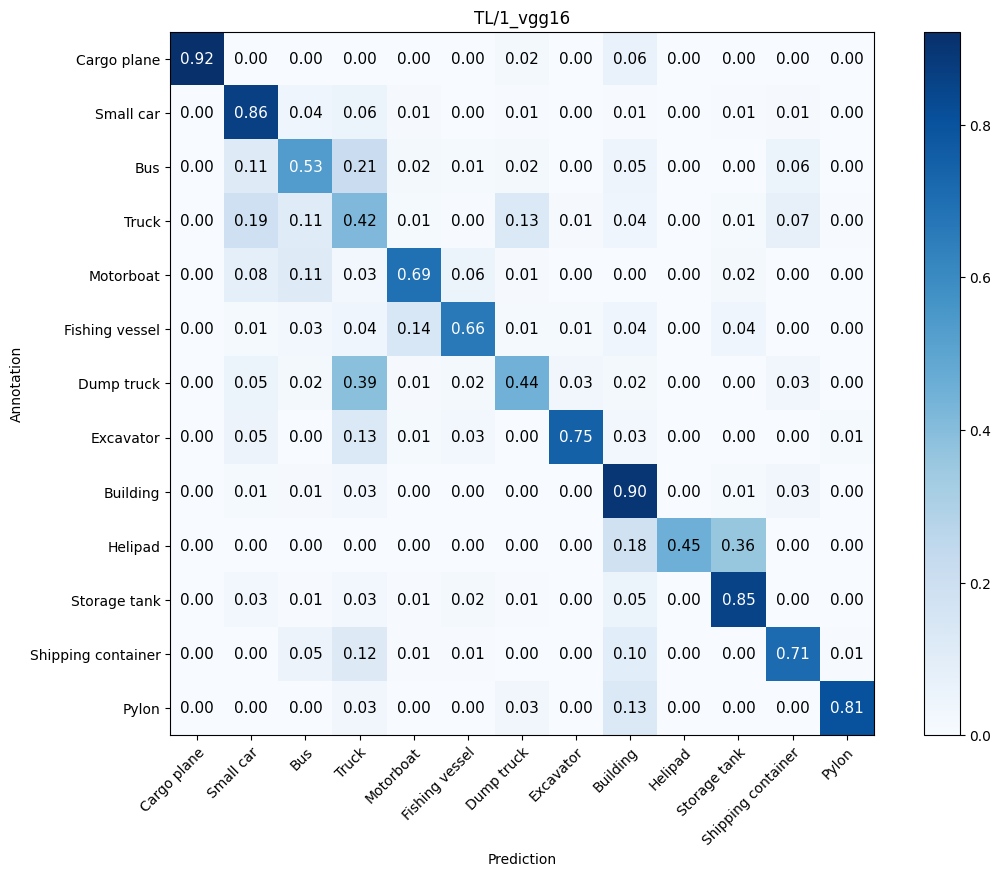

In [14]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.values()))
draw_confusion_matrix(cm, categories, CM_PATH, EXPERIMENT_NAME)

In [15]:
ll = []
# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
global_acc = acc.mean()
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
global_recall = acc.mean()
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
global_precision = acc.mean()
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    ll.append(pd.Series([recall, precision, specificity, f1_score], name=categories[idx], index=["Recall", "Precision", "Specificity", "F1 Score"]))
ll = pd.DataFrame(ll)
sizes_col=pd.Series(y_true).value_counts()
sizes_col.name="Size"
ll = pd.concat([sizes_col, ll, pd.Series([EXPERIMENT_NAME for _ in categories], name='Experiment', index=categories.values())],axis=1)
ll.index.name='Category'
ll = ll.reset_index().set_index(['Experiment','Category'])
ll['Accuracy'] = np.nan
ll.loc[(EXPERIMENT_NAME, 'Global'), ['Size', 'Recall', 'Precision', 'Accuracy']] = [ll.Size.sum().astype(int), global_recall, global_precision, global_acc]
ll = ll.sort_values('Size', ascending=False)
ll.to_csv(METRICS_PATH)
ll.transpose()

Mean Accuracy: 72.107%
Mean Recall: 69.202%
Mean Precision: 76.579%


Experiment    TL/1_vgg16                                                  \
Category          Global    Building   Small car       Truck         Bus   
Size         1875.000000  359.000000  332.000000  221.000000  177.000000   
Recall          0.765790    0.899721    0.861446    0.416290    0.531073   
Precision       0.765790    0.845550    0.760638    0.377049    0.587500   
Specificity          NaN    0.961082    0.941672    0.908102    0.961131   
F1 Score             NaN    0.871795    0.807910    0.395699    0.557864   
Accuracy        0.692016         NaN         NaN         NaN         NaN   

Experiment                                                           \
Category    Shipping container Storage tank  Dump truck   Motorboat   
Size                152.000000   147.000000  124.000000  107.000000   
Recall                0.710526     0.850340    0.443548    0.691589   
Precision             0.710526     0.868056    0.585106    0.755102   
Specificity           0.974463     0.989005    0.977727    0.986425   
F1 Score              0.710526     0.859107    0.504587    0.721951   
Accuracy                   NaN          NaN         NaN         NaN   

Experiment                                                               
Category     Excavator Fishing vessel Cargo plane      Pylon    Helipad  
Size         79.000000      71.000000   64.000000  31.000000  11.000000  
Recall        0.746835       0.661972    0.921875   0.806452   0.454545  
Precision     0.880597       0.723077    1.000000   0.862069   1.000000  
Specificity   0.995546       0.990022    1.000000   0.997831   1.000000  
F1 Score      0.808219       0.691176    0.959350   0.833333   0.625000  
Accuracy           NaN            NaN         NaN        NaN        NaN

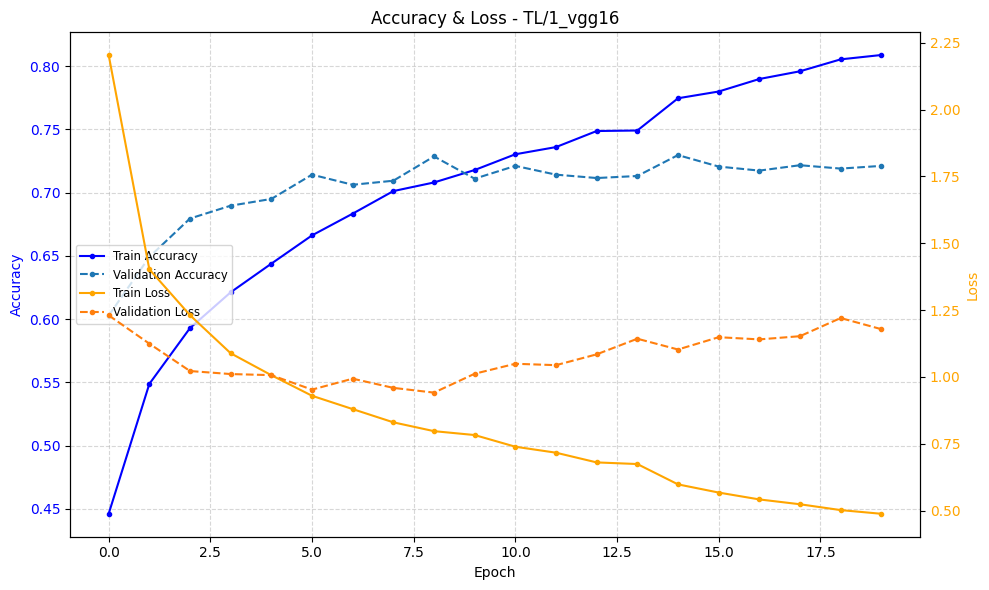

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 6))

plt.title(f'Accuracy & Loss - {EXPERIMENT_NAME}')
ax1.set_xlabel('Epoch')

color_acc = 'blue'
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.plot(h.history['accuracy'], label='Train Accuracy', color='blue', marker='.')
ax1.plot(h.history['val_accuracy'], label='Validation Accuracy', color='tab:blue', linestyle='--', marker='.')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color_loss = 'orange'
ax2.set_ylabel('Loss', color=color_loss)
ax2.plot(h.history['loss'], label='Train Loss', color='orange', marker='.')
ax2.plot(h.history['val_loss'], label='Validation Loss', color='tab:orange', linestyle='--', marker='.')
ax2.tick_params(axis='y', labelcolor=color_loss)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', frameon=True, fontsize='small')

fig.tight_layout()

plt.savefig(ACC_LOSS_PATH, bbox_inches='tight', dpi=300)

plt.show()

# Testing
Try to improve the results provided in the competition.

In [17]:
anns = []
for (dirpath, dirnames, filenames) in os.walk(os.path.join(XVIEW_RECOGNITION_PATH, 'xview_test')):
    for filename in filenames:
        image = GenericImage(os.path.join(dirpath,filename))
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = dirpath[dirpath.rfind('/')+1:]
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [19]:
# model = tf.keras.models.load_model(MODEL_PATH)
predictions_data = {"images": {}, "annotations": {}}
for idx, ann in enumerate(anns):
    image_data = {"image_id": ann.filename.split('/')[-1], "filename": ann.filename, "width": int(ann.tile[2]), "height": int(ann.tile[3])}
    predictions_data["images"][idx] = image_data
    # Load image
    image = load_geoimage(ann.filename)
    for obj_pred in ann.objects:
        # Generate prediction
        warped_image = np.expand_dims(image, 0)
        predictions = model.predict(warped_image, verbose=0)
        # Save prediction
        pred_category = list(categories.values())[np.argmax(predictions)]
        pred_score = np.max(predictions)
        annotation_data = {"image_id": ann.filename.split('/')[-1], "category_id": pred_category, "bbox": [int(x) for x in obj_pred.bb]}
        predictions_data["annotations"][idx] = annotation_data

In [20]:
with open(TEST_PREDICTS_PATH, "w") as outfile:
    json.dump(predictions_data, outfile)